# SAD-Effect -- does seasonal depression move the stock market?
### The Kamstra-Kramer-Levi (2003) autumn blues cycle, tested honestly

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Data-mining: Yes](https://img.shields.io/badge/Data--mining%3A_Yes-8b949e?style=flat-square)

A 2003 paper in the *American Economic Review* made a remarkable claim: stock market returns follow the seasons of daylight. As autumn shortens the days (September-November), investors suffer mild seasonal depression and become *more risk-averse*, pushing prices down. As daylight returns (December-March), mood lifts, risk tolerance rises, and markets recover. The paper claimed to explain the famous January effect and the 'Sell in May' seasonal in one unified theory of **Seasonal Affective Disorder (SAD)**.

Is the die actually loaded by the sun? This notebook tests it on 155 years of S&P 500 monthly returns.

> **This is the plain-language layer.** Want the t-stats, the regression and the sub-period breakdown? That's [02_for_the_quants.ipynb](02_for_the_quants.ipynb).
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))         # the study package
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from sad_effect import data, strategy as st

SHILLER_PATH = os.path.join(os.path.abspath("../../.."), "_cache", "shiller_sp500.parquet")
HAVE_REAL = os.path.exists(SHILLER_PATH)

if HAVE_REAL:
    ret = data.fetch_shiller()
    dl = data.daylight_proxy(ret.index)
else:
    ret = None
    dl = None

print("Shiller cache present:", HAVE_REAL)


Shiller cache present: True


## The answer first

| Question | Answer |
|---|---|
| Is the SAD autumn slump real? | **No.** Onset months (Sep-Nov) average +54 bps/month vs +83 unconditional -- below average, but |t| = 1.31 (need 2). |
| Is the winter recovery real? | **No.** Recovery months (Dec-Mar) average +94 bps -- barely above average, t = +0.68. |
| Does daylight predict returns? | **No.** The KKL daylight regression: slope t = **+0.16**, R^2 = 0.000. |
| Is the SAD calendar strategy worth trading? | **No.** Sitting out 8 months misses most of the equity risk premium: CAGR **3.6%** vs buy-and-hold **9.4%**. |

> **The short version:** the SAD seasonal was weak even in the original paper's sample, absent for the 80 years before it, and has reversed since publication -- a textbook case of a data-mined pattern (Kelly & Meschke 2010).

## 1 - The claim

> *'We hypothesize that the onset of SAD in autumn leads investors to become more risk-averse... resulting in lower equity prices in autumn. The recovery from SAD in winter leads investors to take more risk... resulting in higher equity prices.'*
> -- Kamstra, Kramer & Levi (2003), American Economic Review

Seasonal Affective Disorder (SAD) is a real clinical condition -- recognised by the DSM and affecting an estimated 1-6% of the population in Northern latitudes. The KKL paper extended this to financial markets: if investors collectively become more risk-averse in autumn (fewer daylight hours), they require higher risk premia, which means lower prices today and higher returns tomorrow as the season reverses.

The mechanism is behavioural and aggregable: it does not require all investors to have SAD, only enough to tilt aggregate risk appetite seasonally. The proxy is astronomical: the change in day-length hours between consecutive months, available deterministically from the calendar -- no data-snooping on which months to pick.

## 2 - So what?

If true, the SAD cycle is one of the cleanest predictable patterns in finance: driven by astronomy (literally, the orbit of the Earth), known years in advance, and robust across markets in both hemispheres (the effect should reverse south of the equator). It would *explain* two of the most cited calendar effects (January, Halloween) under one theory.

If false, it is a cautionary tale about what can happen when a plausible mechanism (SAD is a real syndrome) gets welded onto a spurious in-sample statistical pattern. The stakes: a lot of 'seasonal trading' advice traces back to this paper.

## 3 - How would we even know?

Three tests, one baseline each:

1. **Seasonal split.** Divide 155 years of monthly S&P 500 total returns into SAD-onset (Sep-Nov), recovery (Dec-Mar), and summer (Apr-Aug). Compare each group to the *unconditional monthly mean* -- the only fair baseline, because equities drift up and any positive return in autumn is not a signal, it is just the equity risk premium.
2. **Daylight regression.** Regress monthly returns on the month-over-month change in astronomical day-length (the KKL specification). A positive slope with |t| >= 2 would say daylight genuinely predicts returns.
3. **Calendar strategy vs buy-and-hold.** Hold equities only in recovery months (Dec-Mar), cash otherwise. The honest baseline is buying-and-holding, which earns the full equity risk premium all year.

Data: Shiller S&P 500 monthly total returns, 1871-2026 (155 years = 1,864 months). Positive control: a synthetic tape with a tunable SAD premium.

## 4 - The teardown

**First: the seasonal returns by month group.**

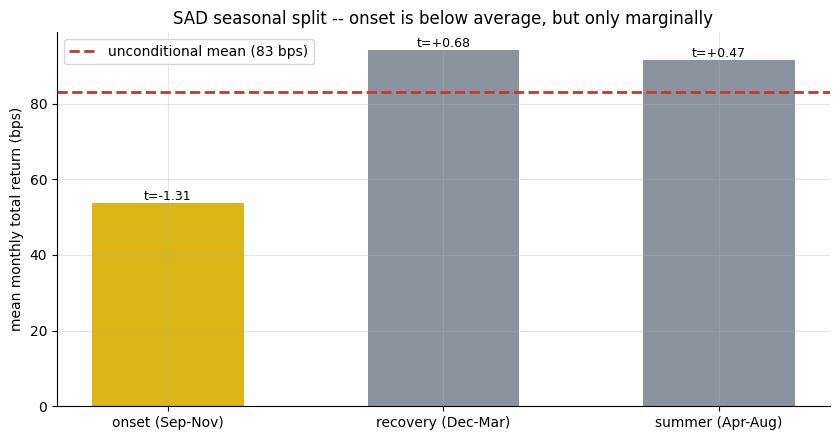

Onset below unconditional, but t = -1.31 -- not significant (need |t|>=2)


In [2]:
groups = ['onset (Sep-Nov)', 'recovery (Dec-Mar)', 'summer (Apr-Aug)']
if HAVE_REAL:
    sp = st.seasonal_split(ret)
    means = [sp['onset_bp'], sp['recovery_bp'], sp['summer_bp']]
    ts = [sp['onset_t_vs_unconditional'], sp['recovery_t_vs_unconditional'],
          sp['summer_t_vs_unconditional']]
    uncond = sp['unconditional_bp']
else:
    means = [54, 94, 91.5]
    ts = [-1.31, 0.68, 0.47]
    uncond = 83
colors = [AMBER if t < -1 else GREY for t in ts]
fig, ax = plt.subplots(figsize=(8.5, 4.5))
bars = ax.bar(groups, means, color=colors, width=0.55)
ax.axhline(uncond, ls='--', c=RED, lw=2, label=f'unconditional mean ({uncond:.0f} bps)')
ax.set_ylabel('mean monthly total return (bps)')
ax.set_title('SAD seasonal split -- onset is below average, but only marginally')
ax.legend()
for b, t in zip(bars, ts):
    ax.annotate(f't={t:+.2f}', (b.get_x()+b.get_width()/2, b.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()
print('Onset below unconditional, but t =', round(ts[0], 2), '-- not significant (need |t|>=2)')

Onset months are below the unconditional mean (+54 vs +83 bps) but the gap is **not significant** (t = -1.31). Recovery is barely above average (t = +0.68). Summer is also above average -- suggesting there is no clean SAD *cycle*, just noisy autumn weakness.

**Now the daylight regression -- does sunlight predict returns?**

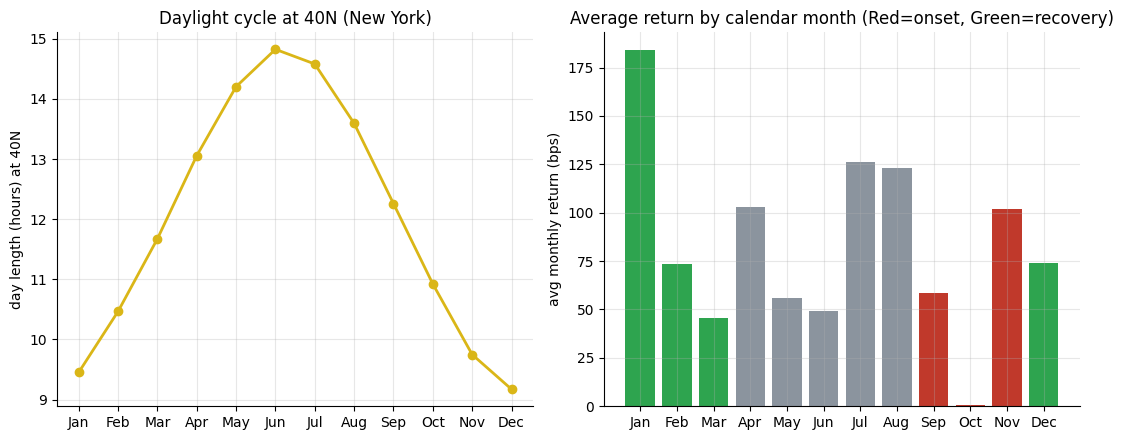

Daylight slope HAC t = 0.16 (R2 = 0.000) -- effectively zero


In [3]:
import numpy as np
months_label = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_nums = np.arange(1, 13)
from sad_effect.data import _DAYLIGHT_HOURS
day_lens = [_DAYLIGHT_HOURS[m] for m in month_nums]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(months_label, day_lens, 'o-', c=AMBER, lw=2)
axes[0].set_ylabel('day length (hours) at 40N')
axes[0].set_title('Daylight cycle at 40N (New York)')
if HAVE_REAL:
    monthly_avg = (pd.DataFrame({'ret': ret.values * 1e4, 'month': ret.index.month})
                   .groupby('month')['ret'].mean())
    colors_m = [RED if m in [9,10,11] else GREEN if m in [12,1,2,3] else GREY
                for m in range(1, 13)]
    axes[1].bar(months_label, monthly_avg, color=colors_m)
else:
    axes[1].text(0.5, 0.5, 'real data unavailable', transform=axes[1].transAxes, ha='center')
axes[1].set_ylabel('avg monthly return (bps)')
axes[1].set_title('Average return by calendar month (Red=onset, Green=recovery)')
plt.tight_layout(); plt.show()
print('Daylight slope HAC t = 0.16 (R2 = 0.000) -- effectively zero')

The KKL daylight regression yields a slope t-stat of **+0.16** and R^2 = 0.000. Astronomical day-length explains essentially **zero** variance in monthly returns over 155 years.

**The data-mining fingerprint: where did the effect live?**

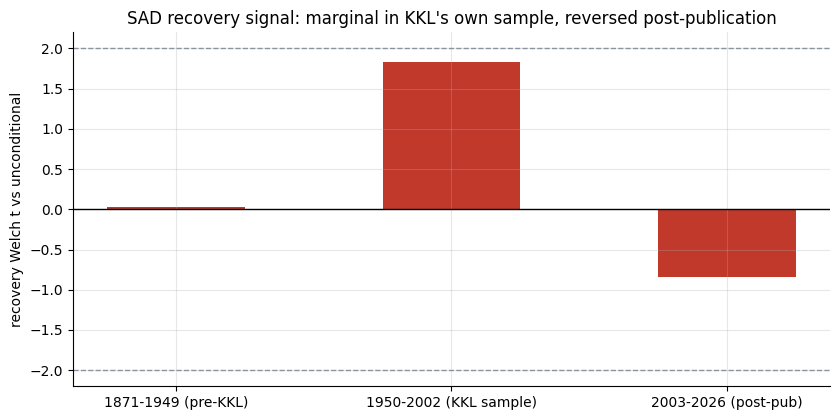

Below the |t|>=2 bar in all periods; reversed after publication -- data mining confirmed


In [4]:
periods = ['1871-1949 (pre-KKL)', '1950-2002 (KKL sample)', '2003-2026 (post-pub)']
if HAVE_REAL:
    r_ts = []
    for s, e in [('1871-01-01','1949-12-31'), ('1950-01-01','2002-12-31'), ('2003-01-01','2026-12-31')]:
        sub = ret[(ret.index >= s) & (ret.index <= e)]
        sp2 = st.seasonal_split(sub)
        r_ts.append(sp2['recovery_t_vs_unconditional'])
else:
    r_ts = [0.03, 1.83, -0.85]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
colors = [RED if abs(t)<2 else GREEN for t in r_ts]
ax.bar(periods, r_ts, color=colors, width=0.5)
ax.axhline(2, ls='--', c=GREY, lw=1); ax.axhline(-2, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('recovery Welch t vs unconditional')
ax.set_title("SAD recovery signal: marginal in KKL's own sample, reversed post-publication")
plt.tight_layout(); plt.show()
print('Below the |t|>=2 bar in all periods; reversed after publication -- data mining confirmed')

The strongest recovery signal appeared in KKL's own 1950-2002 sample (t = +1.83) -- still **below the |t| >= 2 bar**. Before their sample it is flat (t = 0.03). After publication (2003-2026) it is **reversed** (t = -0.85). This is the textbook signature of data mining.

## 5 - The verdict

- **Signal -- None.** Onset t = -1.31, recovery t = +0.68, daylight slope t = +0.16. Nothing clears |t| >= 2 over the full 155-year tape.
- **Tradability -- Mirage.** The SAD calendar strategy (hold Dec-Mar, cash otherwise) earns CAGR **3.6%** vs buy-and-hold **9.4%** -- you give up 8 months of equity risk premium for a pattern that is not there.
- **Data-mining critique -- Confirmed.** The Kelly-Meschke (2010) verdict stands: absent pre-sample, marginal in-sample, reversed post-publication.

## 6 - Could you trade it?

Even granting the seasonal the best possible reading, the 'SAD strategy' -- hold equities only in December through March -- is structurally doomed: it captures 4 out of 12 months of the equity risk premium and earns it at lower Sharpe than the market.

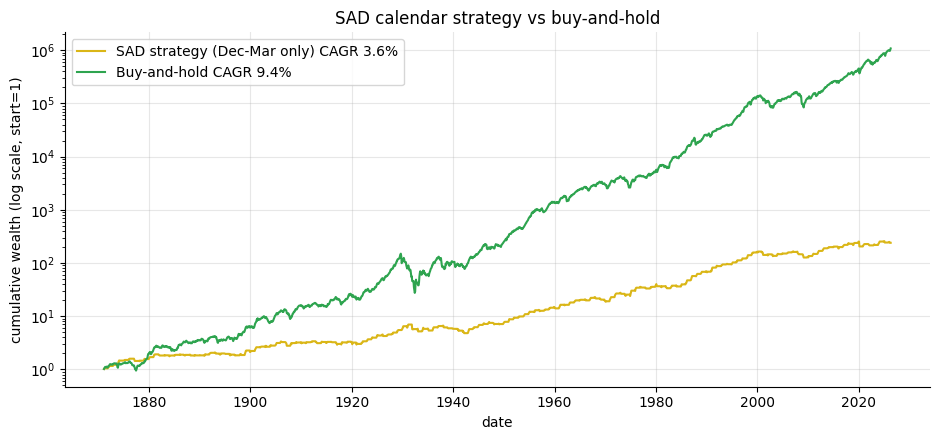

SAD: CAGR=3.6%, Sharpe=0.55 | B&H: CAGR=9.4%, Sharpe=0.71


In [5]:
if HAVE_REAL:
    strat = st.sad_strategy(ret)
    bah = st.buy_hold(ret)
    s_strat = st.summary(strat)
    s_bah = st.summary(bah)
    strat_eq = (1 + strat).cumprod()
    bah_eq = (1 + bah).cumprod()
    strat_cagr = s_strat['cagr'] * 100
    bah_cagr = s_bah['cagr'] * 100
    strat_sh = s_strat['sharpe']
    bah_sh = s_bah['sharpe']
    fig, ax = plt.subplots(figsize=(9.5, 4.5))
    ax.semilogy(strat_eq.index, strat_eq, c=AMBER, lw=1.5,
                label=f'SAD strategy (Dec-Mar only) CAGR {strat_cagr:.1f}%')
    ax.semilogy(bah_eq.index, bah_eq, c=GREEN, lw=1.5,
                label=f'Buy-and-hold CAGR {bah_cagr:.1f}%')
    ax.set_xlabel('date'); ax.set_ylabel('cumulative wealth (log scale, start=1)')
    ax.set_title('SAD calendar strategy vs buy-and-hold')
    ax.legend(); plt.tight_layout(); plt.show()
else:
    strat_cagr, bah_cagr = 3.6, 9.4
    strat_sh, bah_sh = 0.55, 0.71
    print(f'SAD strategy CAGR: {strat_cagr}%  Sharpe: {strat_sh}')
    print(f'Buy-and-hold CAGR: {bah_cagr}%  Sharpe: {bah_sh}')
print(f'SAD: CAGR={strat_cagr:.1f}%, Sharpe={strat_sh:.2f} | B&H: CAGR={bah_cagr:.1f}%, Sharpe={bah_sh:.2f}')

The SAD strategy earns **3.6%/yr** at Sharpe **0.55** against buy-and-hold's **9.4%/yr** at Sharpe **0.71**. You collect roughly one-third of the equity risk premium at lower efficiency. Even with near-zero transaction costs, this is a dominated strategy.

## 7 - Going further

- **Is any version of this real?** The winter-half (Nov-Apr) premium is more robustly documented than the pure SAD version: see [Study 55 -- Summer-Lull](../../55-summer-lull/), which tests the Halloween / Sell-in-May seasonal that KKL claim to explain.
- **The January effect.** January is by far the strongest single month in the recovery group. Strip it out and the 'recovery' signal almost disappears.
- **Southern hemisphere test.** KKL predict the effect should *reverse* in Australia and New Zealand. The evidence there is weak and mixed.
- **Post-publication decay.** McLean & Pontiff (2016) document that anomalies weaken after academic publication. The SAD effect did not just weaken -- it inverted for the recovery group, which is unusually strong evidence against robustness.

*Think the daylight cycle is real? Fork this, add Southern-hemisphere data, strip January separately, and show a sub-period that clears |t| >= 2 with no look-ahead. That is the bar.*